# ```sampley``` exemplar: Stage 1
Before going through this exemplar, please consult the _Introduction to sampley exemplars_ (```intro.ipynb```).
<br>This exemplar illustrates the classes that can be made in Stage 1, their class methods, their attributes, and their methods.

## Setup

### Import the package

In [1]:
from sampley import *

### Set the import folder
To run this exemplar, download the mock data files, put them in a folder, and set the path to the folder below.

In [2]:
import_folder = './import/'

### Set the export folder
To run this exemplar, make a folder to save the samples in and set the path to the folder below.

In [3]:
export_folder = './export/'

## DataPoints

### Make a ```DataPoints``` object...
We can make a ```DataPoints``` object from a CSV, XLSX, GPKG, or SHP file with the ```DataPoints.from_file()``` class method. The method is the same, regardless of file type, but we will need to specify a few extra parameters if importing a CSV or XLSX.

#### ...from a CSV (or XLSX) with x and y coordinates

In [4]:
u_datapoints = DataPoints.from_file(
    filepath=import_folder+'sightings.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


#### ...from a GPKG (or SHP)

In [5]:
u_datapoints = DataPoints.from_file(
    filepath=import_folder+'sightings.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


### Access a ```DataPoints``` object's attributes
A ```DataPoints``` object, regardless of how it was made, will have three attributes (```name```, ```parameters```, and ```datapoints```) that we can access as follows.

In [6]:
u_datapoints.name

'datapoints-sightings'

In [7]:
u_datapoints.parameters

{'datapoints_filepath': './import/sightings.gpkg',
 'datapoints_crs': 'EPSG:32619',
 'datapoints_tz': 'UTC-05:00',
 'datapoints_data_cols': 'individuals, season'}

In [8]:
u_datapoints.datapoints

,datapoint_id,geometry,datetime,individuals,season
0,d01,POINT (579166.78 4742872.701),2019-01-25 10:18:32-05:00,1,winter
1,d02,POINT (554184.217 4742741.886),2019-01-25 10:26:55-05:00,2,winter
2,d03,POINT (548599.876 4742700.214),2019-01-25 10:28:47-05:00,5,winter
3,d04,POINT (520909.741 4714855.058),2019-03-02 12:50:31-05:00,1,spring
4,d05,POINT (532548.249 4714899.835),2019-03-02 12:54:32-05:00,2,spring
5,d06,POINT (512817.407 4705582.465),2019-03-02 13:47:02-05:00,1,spring
6,d07,POINT (504710.41 4705553.392),2019-03-02 13:49:42-05:00,3,spring
7,d08,POINT (654449.136 4716189.584),2019-03-05 12:09:08-05:00,5,spring
8,d09,POINT (645666.237 4716110.937),2019-03-05 12:12:21-05:00,2,spring
9,d10,POINT (643532.681 4716066.52),2019-03-05 12:13:08-05:00,1,spring


### Plot a ```DataPoints``` object
```DataPoints``` objects have an inbuilt ```plot``` method to make a simple plot.

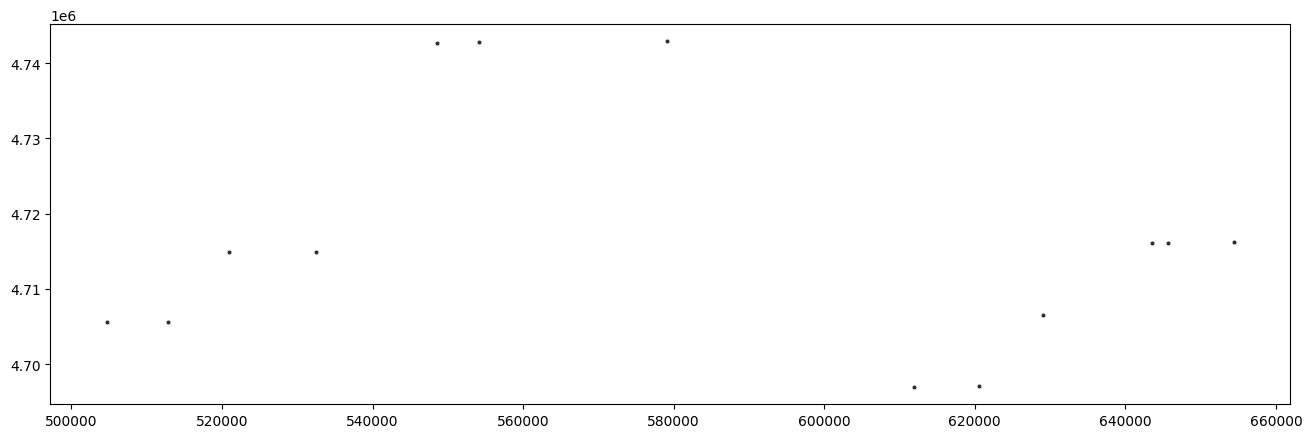

In [9]:
u_datapoints.plot()

### Save a ```DataPoints``` object
```DataPoints``` objects have an inbuilt ```save``` method to save the datapoints as a CSV or GPKG.

In [10]:
u_datapoints.save(
    folder=export_folder)

## Sections

### Make a ```Sections``` object...
We can make a ```Sections``` object from a GPKG or SHP file with the ```Sections.from_file()``` class method. Alternatively, we can make a ```Sections``` object from a ```DataPoints``` object with the ```Sections.from_datapoints()``` class method.

#### ...from a GPKG (or SHP)

In [11]:
u_sections = Sections.from_file(
    filepath=import_folder+'sections.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: section IDs generated.


#### ...from a ```DataPoints``` object
Although in the example below we make a ```DataPoints``` object from a CSV, the ```DataPoints``` object could be made from any file type (i.e., CSV, XLSX, GPKG or SHP) as demonstrated above.

In [12]:
u_datapoints = DataPoints.from_file(  # first make a DataPoints object (from a CSV, XLSX, GPKG, or SHP)
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    section_id_col='section_id'  
)
u_sections = Sections.from_datapoints(datapoints=u_datapoints)  # then make the Sections object from the DataPoints object

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


### Access a ```Sections``` object's attributes
A ```Sections``` object, regardless of how it was made, will have three attributes (```name```, ```parameters```, and ```sections```) that we can access as follows.

In [13]:
u_sections.name

'sections-trackpoints'

In [14]:
u_sections.parameters

{'sections_filepath': './import/trackpoints.csv (via datapoints)',
 'sections_crs': 'EPSG:32619',
 'sections_tz': 'UTC-05:00'}

In [15]:
u_sections.sections

,section_id,geometry,datetime
0,s001,"LINESTRING (580092.757 4742883.408, 579997.135...",2019-01-25 10:18:13-05:00
1,s002,"LINESTRING (592927.566 4733678.432, 592818.466...",2019-01-30 14:32:57-05:00
2,s003,"LINESTRING (500383.195 4714750.316, 500765.569...",2019-03-02 12:43:27-05:00
3,s004,"LINESTRING (656499.299 4751214.73, 656509.418 ...",2019-03-05 11:21:16-05:00


### Plot a ```Sections``` object
```Sections``` objects have an inbuilt ```plot``` method to make a simple plot.

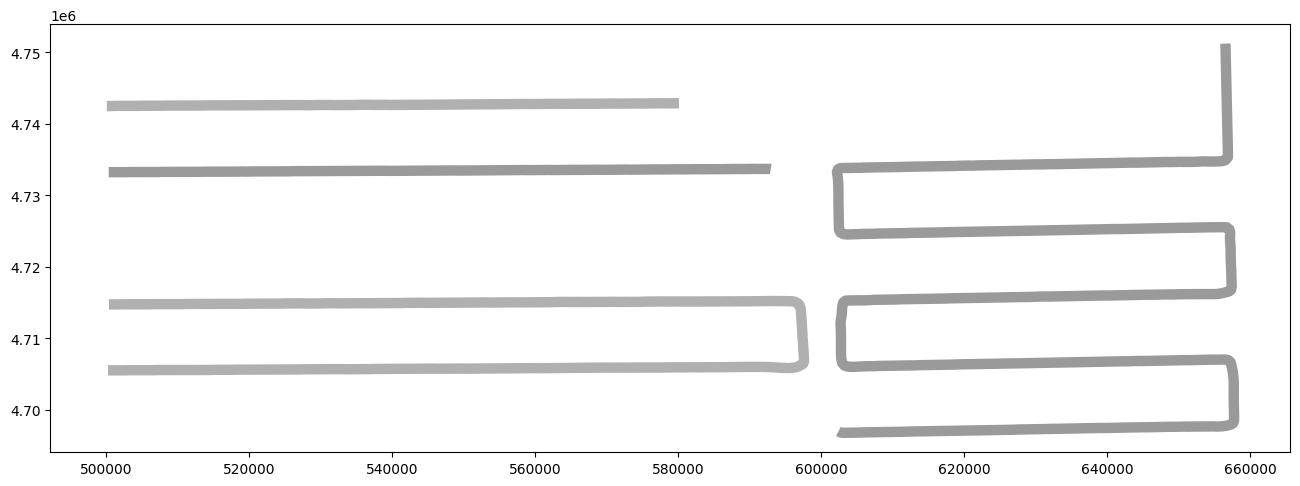

In [16]:
u_sections.plot()

### Save a ```Sections``` object
```Sections``` objects have an inbuilt ```save``` method to save the sections as a CSV or GPKG.

In [17]:
u_sections.save(folder=export_folder)